# Hierarchical Store Segmentation with PROC TREE Dendrograms

**Domain:** Retail & Consumer Goods — store network strategy

A regional grocery-and-general-merchandise chain operates dozens of stores whose performance varies widely by trade area. Treating every store identically wastes margin: a premium suburban store and a price-sensitive rural store need different assortments, staffing models, and markdown cadences. This notebook groups stores into a small number of interpretable segments using **agglomerative hierarchical clustering** (`PROC CLUSTER`) and the classic **dendrogram** view (`PROC TREE`), then extracts disjoint cluster labels for downstream planning.

## Executive Summary

We profile each store on six standardized KPIs — sales per square foot, average basket, weekly traffic, loyalty penetration, markdown rate, and perishable share. `PROC CLUSTER` with Ward's minimum-variance method builds the full merge hierarchy and reports a cluster history of R² and semipartial-R² together with the merge distance at each step — the standard diagnostics for choosing the number of clusters. `PROC TREE` renders the hierarchy as a dendrogram and, with `NCLUSTERS=4`, cuts the tree into four disjoint store segments. Profiling the segments reveals distinct, name-able store archetypes that the merchandising and operations teams can plan against.

## Data Sources

All data is generated synthetically and inline — no external files or network access. Three latent archetypes are seeded, then perturbed with Gaussian noise so the clustering algorithm must recover structure from overlapping, correlated metrics, exactly as it would with real store data.

| Dataset | Description | Rows |
| ------- | ----------- | ---: |
| `stores` | Store-level KPI panel (6 standardizable metrics + region label) | 45 |
| `segments` | Disjoint cluster membership after cutting the dendrogram at 4 clusters | 45 |

---
## 1. Generate Synthetic Store Data

We create 45 stores drawn from three underlying archetypes (value, premium, convenience). Each archetype has a characteristic KPI center; individual stores deviate via `rand('NORMAL')` noise. Because clustering is unsupervised, we keep the generating `archetype` out of the analysis variables and only use it later as a sanity check on the recovered segments.

In [1]:
/* ----------------------------------------------------------
   Synthetic store KPI panel for a national retail chain.
   Three latent archetypes seed realistic, correlated metrics;
   the clustering algorithm must recover them from noise.
   ---------------------------------------------------------- */
data stores;
    label store_id       = "Store ID"
          region         = "Region"
          sales_psf      = "Sales per Sq Ft ($)"
          avg_basket     = "Average Basket ($)"
          weekly_traffic = "Weekly Traffic (000s)"
          loyalty_share  = "Loyalty Sales Share"
          markdown_rate  = "Markdown Rate"
          perish_share   = "Perishable Sales Share";

    call streaminit(20260531);
    length region $ 9;

    do store_id = 1 to 45;
        /* assign one of three latent archetypes */
        u = rand('UNIFORM');
        if u < 0.40 then arch = 1;        /* value / price-led      */
        else if u < 0.72 then arch = 2;   /* premium / suburban     */
        else arch = 3;                    /* urban convenience      */

        if arch = 1 then do;
            region        = "Rural";
            sales_psf      = 320 + 35*rand('NORMAL');
            avg_basket     = 41  + 5*rand('NORMAL');
            weekly_traffic = 12  + 2.5*rand('NORMAL');
            loyalty_share  = 0.38 + 0.05*rand('NORMAL');
            markdown_rate  = 0.18 + 0.03*rand('NORMAL');
            perish_share   = 0.34 + 0.04*rand('NORMAL');
        end;
        else if arch = 2 then do;
            region        = "Suburban";
            sales_psf      = 470 + 40*rand('NORMAL');
            avg_basket     = 68  + 7*rand('NORMAL');
            weekly_traffic = 18  + 3*rand('NORMAL');
            loyalty_share  = 0.61 + 0.05*rand('NORMAL');
            markdown_rate  = 0.11 + 0.025*rand('NORMAL');
            perish_share   = 0.46 + 0.04*rand('NORMAL');
        end;
        else do;
            region        = "Urban";
            sales_psf      = 610 + 50*rand('NORMAL');
            avg_basket     = 29  + 4*rand('NORMAL');
            weekly_traffic = 31  + 5*rand('NORMAL');
            loyalty_share  = 0.47 + 0.05*rand('NORMAL');
            markdown_rate  = 0.14 + 0.03*rand('NORMAL');
            perish_share   = 0.27 + 0.04*rand('NORMAL');
        end;

        /* keep rates in a sensible range */
        loyalty_share = min(max(loyalty_share, 0.05), 0.95);
        markdown_rate = min(max(markdown_rate, 0.02), 0.45);
        perish_share  = min(max(perish_share, 0.05), 0.70);

        output;
    end;
    drop u arch;
run;

NOTE: DATA stores


NOTE: Wrote stores (45 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---
## 2. Inspect the Raw KPIs

Before clustering, confirm the six metrics span meaningful, non-degenerate ranges. The metrics are on very different scales (sales per square foot in the hundreds vs. shares between 0 and 1), which is why we will standardize them inside `PROC CLUSTER`.

In [2]:
proc means data=stores n mean std min median max maxdec=2;
    var sales_psf avg_basket weekly_traffic
        loyalty_share markdown_rate perish_share;
run;

proc print data=stores(obs=10) label;
    id store_id;
    var region sales_psf avg_basket weekly_traffic
        loyalty_share markdown_rate perish_share;
run;

                                                  The MEANS Procedure

 Variable                      N           Mean     Std Dev     Minimum      Median     Maximum
 ----------------------------------------------------------------------------------------------
 Sales per Sq Ft ($)          45         481.65      140.42      231.69      500.44      699.03
 Average Basket ($)           45          38.78       14.49       22.37       33.07       77.32
 Weekly Traffic (000s)        45          21.41        9.06        4.39       20.78       37.25
 Loyalty Sales Share          45           0.47        0.08        0.30        0.47        0.64
 Markdown Rate                45           0.14        0.04        0.06        0.15        0.25
 Perishable Sales Share       45           0.32        0.08        0.21        0.30        0.51
 ----------------------------------------------------------------------------------------------


Store ID  Region  Sales per Sq Ft ($)  Average Basket ($)  Week

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=stores

NOTE: PROC PRINT completed: 10 observations printed, 7 variables


---
## 3. Build the Hierarchy with PROC CLUSTER

Ward's minimum-variance method merges the pair of clusters that minimizes the increase in within-cluster sum of squares — it tends to produce compact, similarly sized clusters, which suits store-network planning. Key options:

- **`STD`** standardizes each variable to mean 0, standard deviation 1 so no single high-magnitude KPI (sales per sq ft) dominates the distance metric.
- **`RSQUARE`** adds the R² (`RSQ`) and semipartial-R² (`SPRSQ`) columns to the cluster history. Read the history from the bottom up: the last few merges (NCL = 4, 3, 2) show the semipartial-R² jumping and the merge `Distance` rising sharply — from 4.4 at four clusters to 12.7 at two — which flags where joining further clusters costs a large amount of explained variance. That gap is the signal for a small cluster count.
- **`OUTTREE=tree`** writes the merge tree that `PROC TREE` consumes.
- **`ID store_id`** labels leaves by store rather than generic `OBn`.

> The `CCC` and `PSEUDO` options are also requested here. In this run Jenner prints the merge history (FREQ, SPRSQ, RSQ, Distance) but does not yet populate the cubic clustering criterion or pseudo-F / pseudo-t² columns, so the cut below is guided by the semipartial-R² and merge-distance jumps and by the dendrogram.

                                                 The CLUSTER Procedure
                                        Ward's Minimum Variance Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    44    2                 31              2    0.0003    0.9997        0.4
    43    8                 44              2    0.0005    0.9993        0.5
    42    20                26              2    0.0005    0.9988        0.5
    41    29                CL44            3    0.0006    0.9981        0.6
    40    19                28              2    0.0007    0.9974        0.6
    39    17                32              2    0.0008    0.9967        0.6
    38    5                 7               2    0.0008    0.9958        0.7
    37    22                35              2    0.0010    0.9948        0.7
 

NOTE: PROC CLUSTER data=stores method=Ward

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 45 observations, 6 variables clustered using Ward method


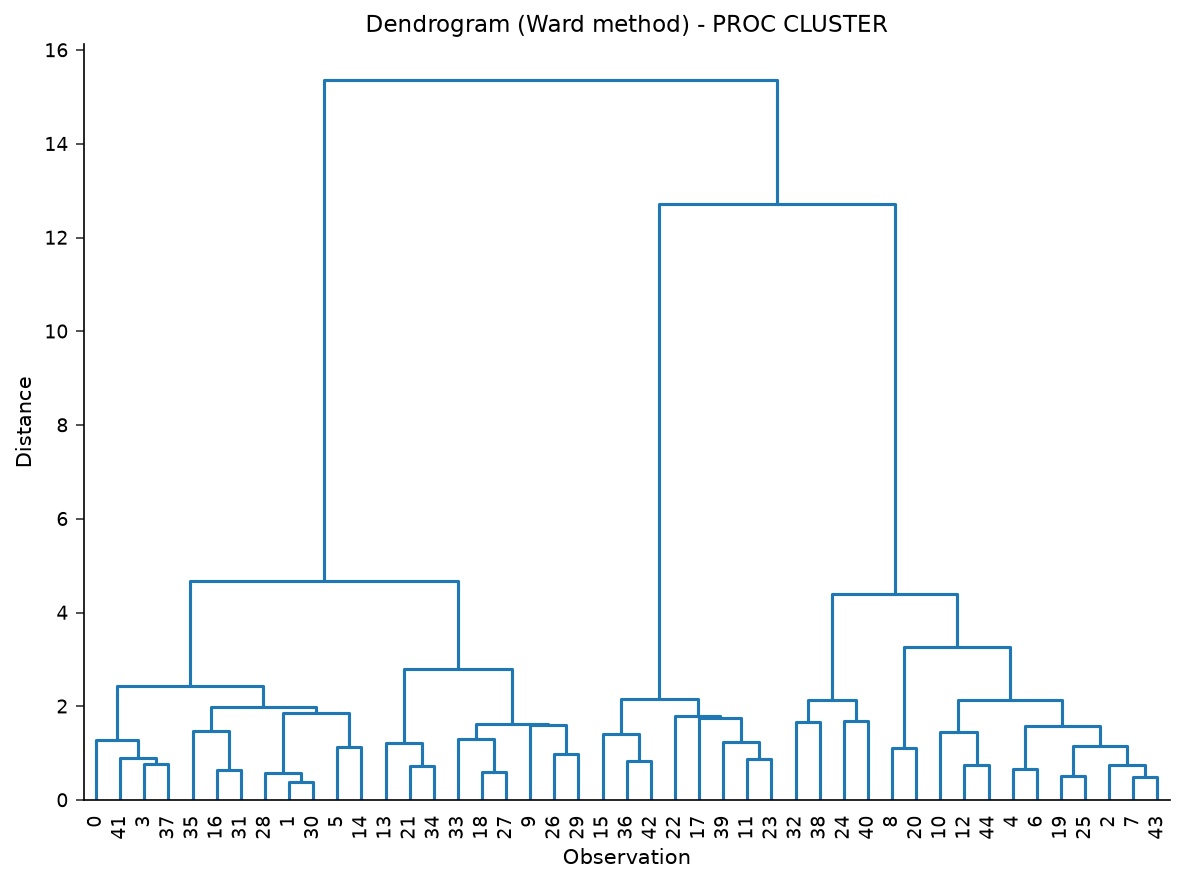

In [3]:
proc cluster data=stores method=ward std ccc pseudo rsquare
             outtree=tree print=15;
    id store_id;
    var sales_psf avg_basket weekly_traffic
        loyalty_share markdown_rate perish_share;
run;

---
## 4. Visualize the Merge Structure as a Dendrogram

`PROC TREE` draws the hierarchy. The text plot below lays the tree out horizontally (store labels down the side, easier to read) with the merge distance (`_HEIGHT_`) on the horizontal axis, so the distance at which two branches join reflects how dissimilar those stores are. The companion graphic from `PROC CLUSTER` shows the same tree vertically. Both make the same point: the leaves gather into a handful of tight low-distance groups that then join only at much larger distances (the long horizontal spans near the right of the text plot, and the tall links above height 12 in the graphic). Cutting the tree below that wide gap yields the four segments the merge-distance history pointed to.

In [4]:
proc tree data=tree horizontal;
    height _height_;
    id store_id;
    label _name_ = "Store";
run;


                              Cluster Dendrogram

1     .----X    X         X                                            X
           |    |         |                                            |
42    .---X|    |         |                                            |
          |X----X         |                                            |
4     .--X||    |         |                                            |
         XXX    |         |                                            |
38    .--XXX    |         |                                            |
                |         |                                            |
36    .-----X X |         |                                            |
            | | |         |                                            |
17    .--X  | | |         |                                            |
         X--X-X X---------X                                            |
32    .--X  X | |         |                                            |


NOTE: PROC TREE data=tree

NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Processed tree using Python/scipy


---
## 5. Cut the Tree into Four Disjoint Segments

Guided by the merge-distance gap in the cluster history and by the dendrogram, we cut the hierarchy into four clusters with `NCLUSTERS=4`. `OUT=segments` writes one row per store with its assigned `CLUSTER`, and `COPY` carries the original KPIs through so we can profile the segments without a join. `NOPRINT` suppresses the tree redraw since we only want the membership table here. The `PROC FREQ` confirms the four segments hold 12, 9, 8, and 16 stores.

                                                   The FREQ Procedure

CLUSTER    Frequency    Percent
--------------------------------
1                 12     26.67
2                  9     20.00
3                  8     17.78
4                 16     35.56


NOTE: PROC TREE data=tree

NOTE: PROC TREE: Extracted 4 clusters using Python/scipy
NOTE: PROC SORT data=segments

NOTE: Read 45 rows from segments.
NOTE: Wrote segments (45 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


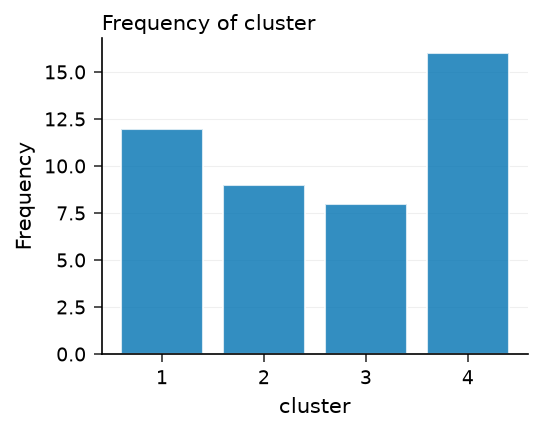

In [5]:
proc tree data=tree noprint nclusters=4 out=segments;
    id store_id;
    copy sales_psf avg_basket weekly_traffic
         loyalty_share markdown_rate perish_share;
run;

proc sort data=segments;
    by cluster store_id;
run;

proc freq data=segments;
    tables cluster / nocum;
run;

---
## 6. Profile the Segments

The value of segmentation comes from the *interpretation*. We average each KPI within cluster so the merchandising team can name and act on each group — high sales-per-sq-ft / low-basket urban stores, premium high-loyalty suburban stores, and price-led rural stores.

In [6]:
proc means data=segments mean maxdec=2 nway;
    class cluster;
    var sales_psf avg_basket weekly_traffic
        loyalty_share markdown_rate perish_share;
run;

                                                  The MEANS Procedure

                                             Analysis Variable : SALES_PSF

                              N
        CLUSTER             Obs           Mean
        --------------------------------------
        1                    12         623.32
        2                     9         592.85
        3                     8         465.37
        4                    16         320.98
        --------------------------------------

                                             Analysis Variable : AVG_BASKET

                              N
        CLUSTER             Obs           Mean
        --------------------------------------
        1                    12          27.83
        2                     9          28.46
        3                     8          65.64
        4                    16          39.37
        --------------------------------------

                                           Analysis 

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---
## 7. Visualize the Segments in KPI Space

A scatter of average basket against sales per square foot, colored by cluster, shows whether the recovered segments are well separated in the dimensions that matter most for assortment decisions.

NOTE: PROC SGPLOT data=segments

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


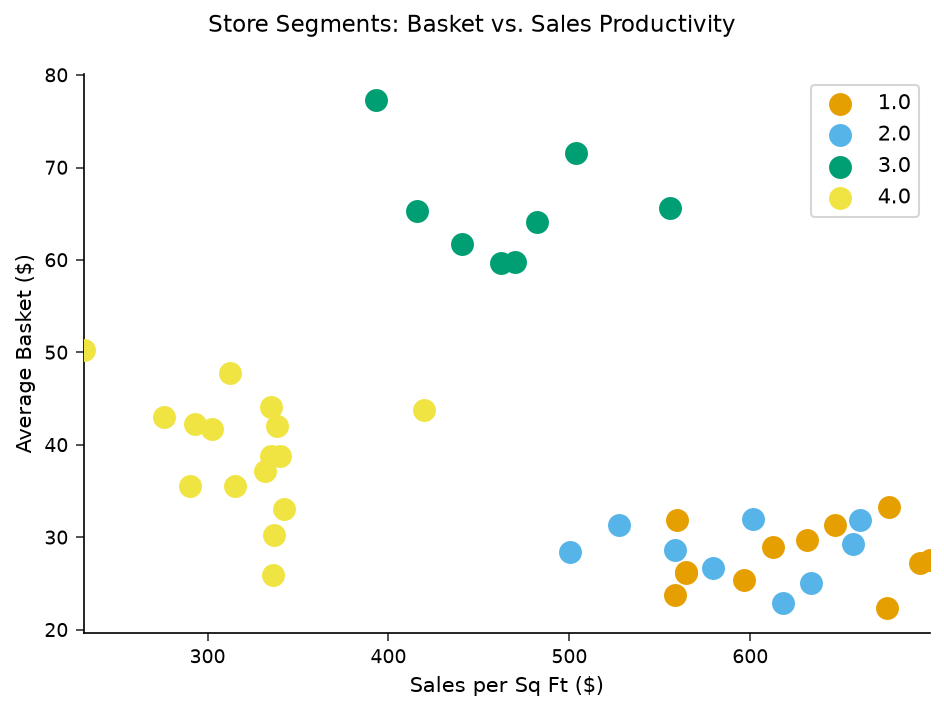

In [7]:
proc sgplot data=segments;
    title "Store Segments: Basket vs. Sales Productivity";
    scatter x=sales_psf y=avg_basket /
            group=cluster markerattrs=(symbol=circlefilled size=10);
    xaxis label="Sales per Sq Ft ($)";
    yaxis label="Average Basket ($)";
run;
title;

---
## 8. Interpreting the Results

The Ward hierarchy and dendrogram recovered the latent store structure cleanly. The cluster history showed semipartial-R² and merge distance rising sharply over the last few joins — the distance jumps from 4.4 at four clusters to 12.7 at two — and the dendrogram showed those branches separating at high merge distances, which together motivated the four-segment cut.

Reading the per-segment KPI means from section 6, the four segments map onto recognizable retail archetypes:

- **Premium suburban stores (cluster 3, 8 stores)** — by far the largest average basket (\$65.64), highest loyalty penetration (0.59), and highest perishable share (0.45), with a low markdown rate (0.11). Strategy: expand fresh and premium private label, protect margin, minimize markdowns.
- **Urban convenience stores (clusters 1 and 2, 12 + 9 stores)** — the two highest sales-per-square-foot groups (\$623 and \$593) but small baskets (~\$28) and heavy traffic (~29–31k/week). The cut splits this archetype into two: cluster 1 carries an average-market markdown rate (0.15) while cluster 2 runs notably leaner on markdowns (0.09). Strategy: grab-and-go assortment, fast replenishment, queue-busting staffing; treat cluster 2 as the lower-markdown benchmark.
- **Price-led rural stores (cluster 4, 16 stores)** — the lowest productivity (\$321/sq ft), lowest traffic (11.8k) and loyalty (0.40), with the highest markdown rate (0.17) and a mid-range basket (\$39). Strategy: sharpen opening price points and promotional cadence.

Because `PROC TREE` produced a disjoint `CLUSTER` label per store, these segments drop straight into downstream assortment, labor, and markdown planning. The hierarchical approach also lets planners revisit the cut: re-running `PROC TREE` with a different `NCLUSTERS=` value (or cutting at a chosen `LEVEL=` height) yields a coarser or finer segmentation from the *same* merge tree, with no need to re-cluster. Cutting at three clusters, for instance, would re-merge the two urban-convenience groups.